In [2]:
from core.general import *

from matplotlib import pyplot as plt
%matplotlib inline

from numpy import nan, inf
import numpy as np

In [3]:
cd('log/sub')

In [4]:
import os

In [5]:
tdl = [f'{i}/main.log' for i in ls() if os.path.isdir(i) and exist(f'{i}/main.log')]

tdl

['CheXpert/main.log',
 'CheXNet-Linear/main.log',
 'CheXNet/main.log',
 'CheXNet-Reverse-Linear/main.log',
 'cheXNet-1024/main.log',
 'CheXNet-TTA/main.log',
 'no-RELU/main.log',
 'cheXNet-ReLU/main.log']

In [6]:
import json

In [7]:
f = [[i.split(' -> ', 1)[0].split('[', 1)[1][:-1], json.loads(i.split(' -> ', 1)[1])] for i in read_from_file(tdl[0]).strip().split('\n')]

In [8]:
import re

DEBUG  False
DEBUG  [0.002492231108404905, 0.0024456275948337818, 0.0024227530649076926, 0.0024054834123764684, 0.0023926843862945787, 0.002299556039807581, 0.0021661275426923905, 0.002069298897012546, 0.0019733573733306726, 0.0018977696914878612, 0.001826439040344545, 0.0017634713807944034, 0.0016774341518442347, 0.001563494682030584, 0.0015118185453250354, 0.0014920461101086107, 0.0014893708857228961, 0.001451603164374132, 0.0014401114295161332, 0.0014268433152207658, 0.0014184875358650433, 0.0013987646424762812, 0.0013678814897406556, 0.0013743828525520118, 0.0013504387257762857, 0.0013315878266314874, 0.001343528287357584, 0.0013196000502759596, 0.0013200504377098446, 0.0012941749842991222, 0.0012810959905564401, 0.0012670752389292664, 0.0012633458524978665, 0.0012421925114453234, 0.001242582007391796, 0.001216729123176531, 0.0012134950030290425, 0.0012068916351180466, 0.0011831678188989096, 0.0011788725328734696, 0.0011712912531755284, 0.001165749923640868, 0.001153424621368918, 0

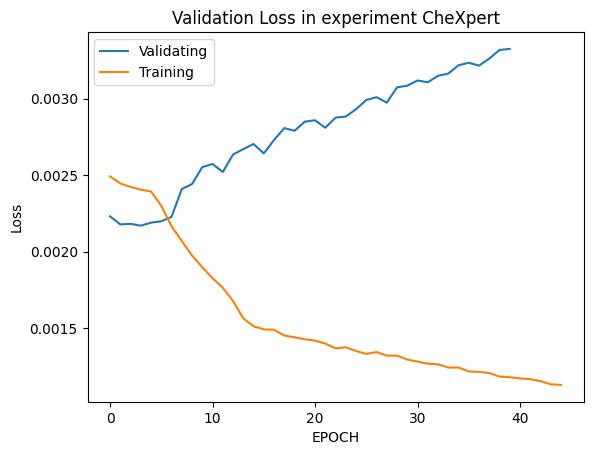

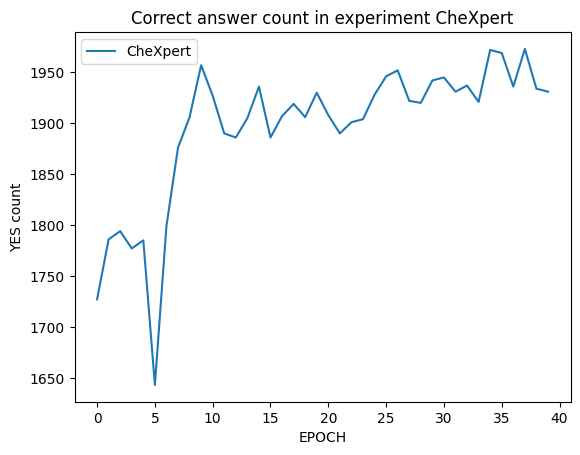

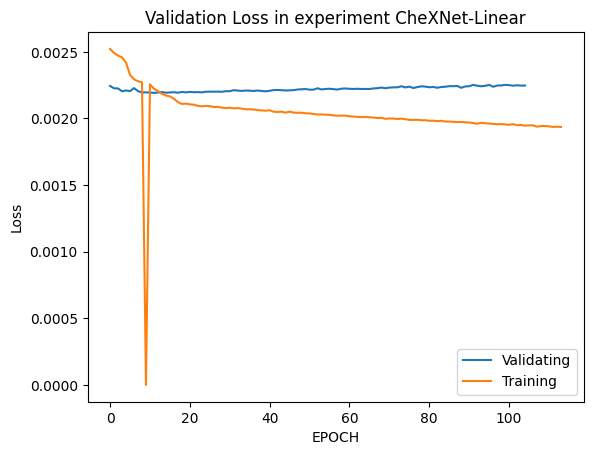

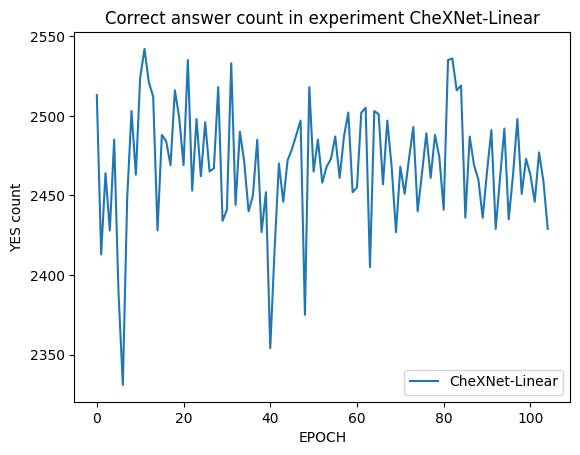

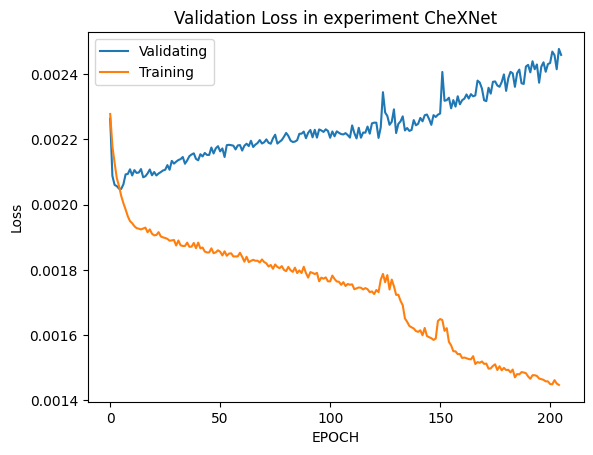

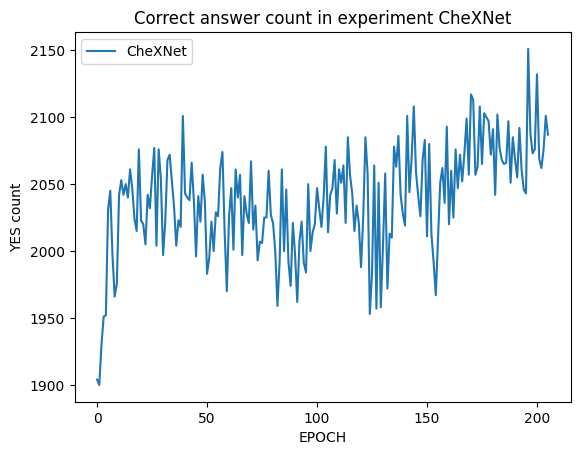

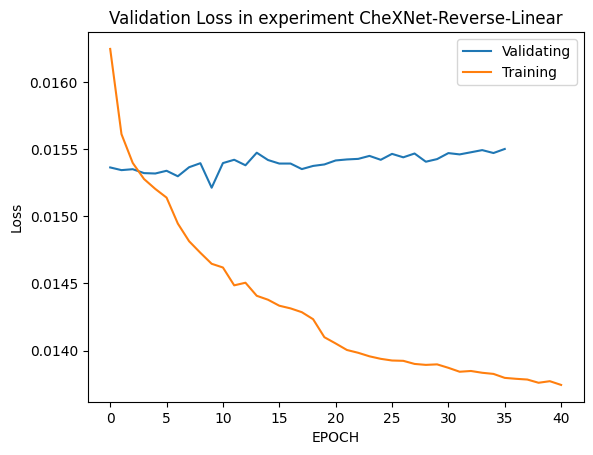

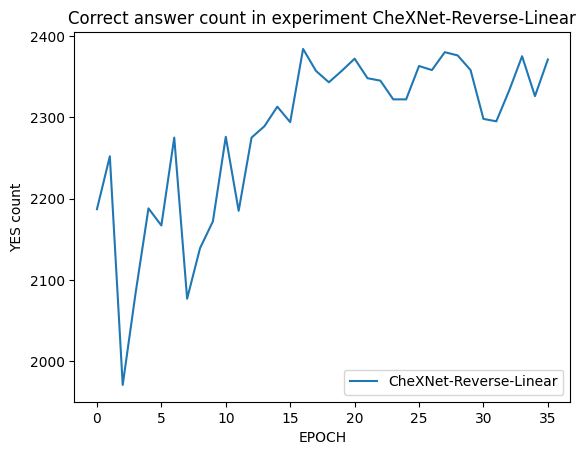

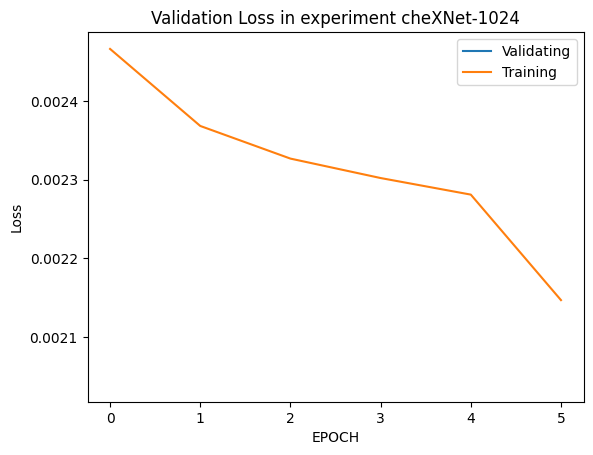

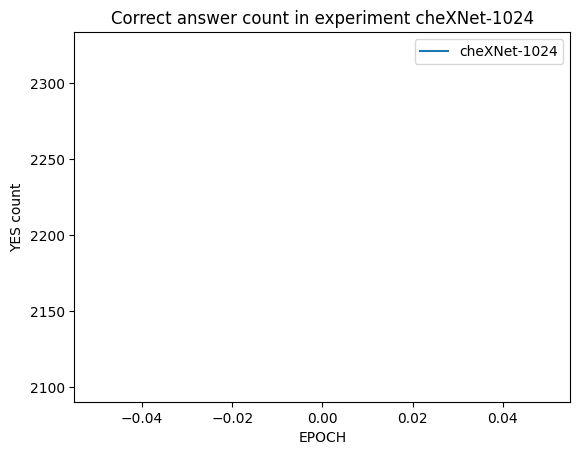

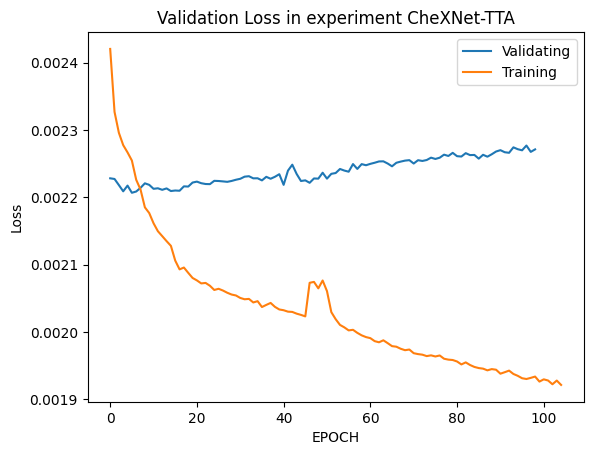

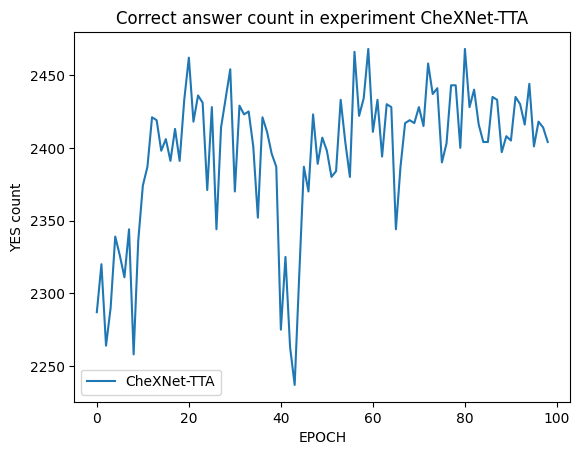

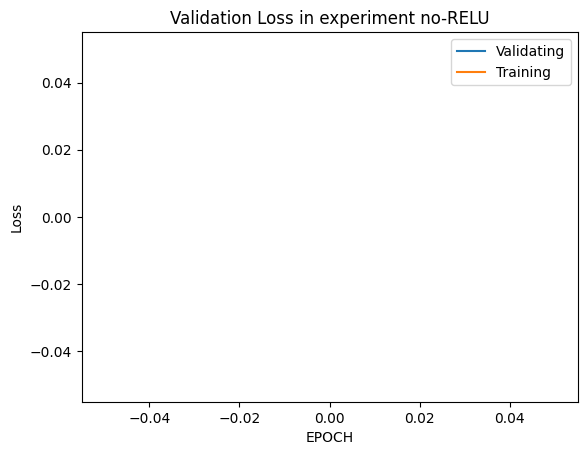

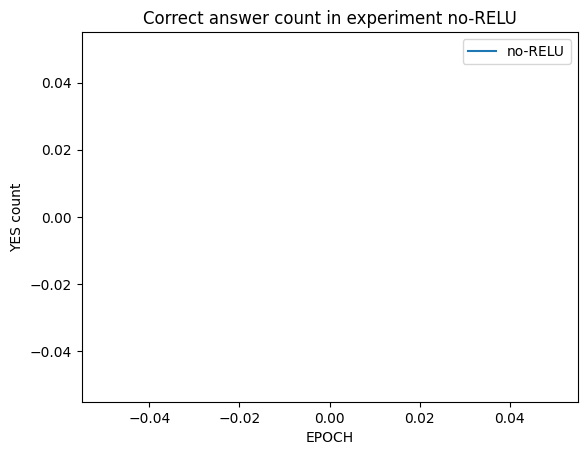

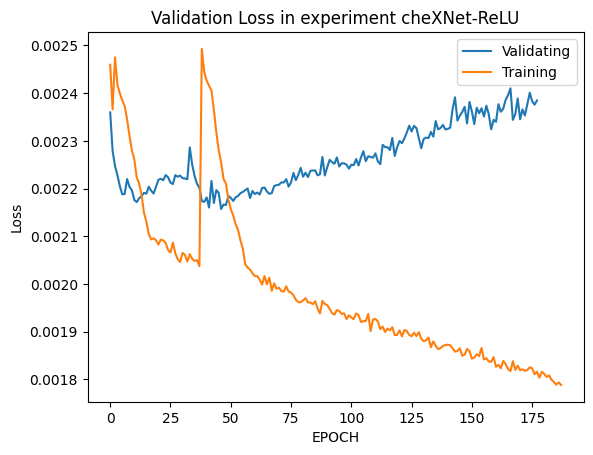

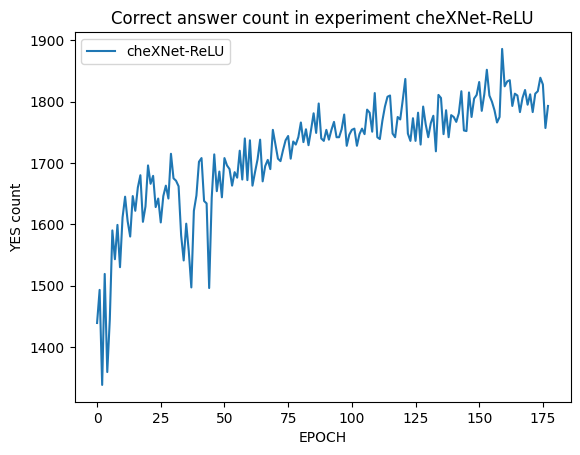

In [9]:
filter = re.compile(r'with loss (\d+\.\d+), saving')
for i in tdl:
    debug(i.startswith('CheXNet/'))
    f = [[i.split(' -> ', 1)[0].split('[', 1)[1][:-1], json.loads(i.split(' -> ', 1)[1])] for i in read_from_file(i).strip().split('\n')]
    if i.startswith('CheXNet/'):
        f = f[3164:]

        # debug(f)

    now = [i for i in f if i[0] == 'Validate' and isinstance(i[1], dict)]
    tri = [float(filter.findall(i[1])[0]) for i in f if i[0] == 'Train' if 'with loss' in i[1]]

    debug(tri)

    val = [i[1]['val'] for i in now]
    yes = [i[1]['yes'] for i in now]

    name = i.split('/', 1)[0]

    plt.figure()

    plt.plot(val, label = 'Validating')
    plt.plot(tri, label = 'Training')
    plt.title(f'Validation Loss in experiment {name}')
    plt.xlabel('EPOCH')
    plt.ylabel('Loss')

    plt.legend(loc = 'best')

    plt.savefig(f'../../figure/{name}-loss.png')

    plt.figure()

    plt.plot(yes, label = name)
    plt.title(f'Correct answer count in experiment {name}')
    plt.xlabel('EPOCH')
    plt.ylabel('YES count')

    plt.legend(loc = 'best')

    plt.savefig(f'../../figure/{name}-yes.png')

In [10]:
pre = '''No Finding -> 2999
Hernia -> 71
Pneumonia -> 202
Fibrosis -> 600
Pleural_Thickening -> 717
Emphysema -> 1010
Edema -> 1113
Cardiomegaly -> 1290
Pneumothorax -> 1433
Mass -> 1803
Nodule -> 1811
Consolidation -> 1920
Effusion -> 1983
Infiltration -> 2904
Atelectasis -> 3065'''

In [11]:
f = [i.split() for i in pre.split('\n')]

f = sorted([[i[0], int(i[-1])] for i in f], key = lambda x: x[1])

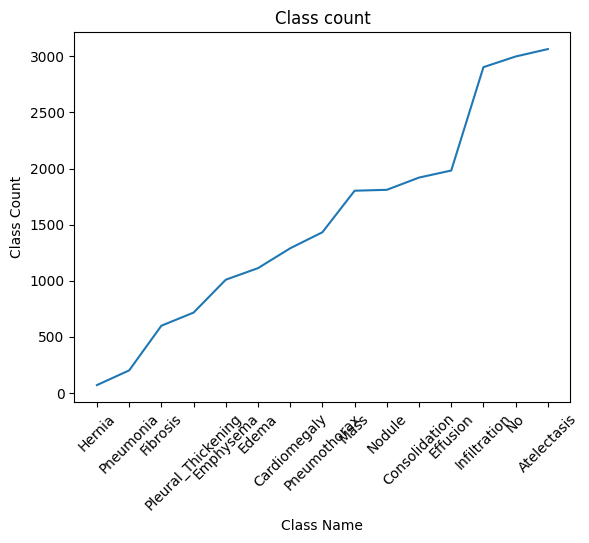

In [13]:
plt.plot([i[0] for i in f], [i[1] for i in f])
plt.xticks(rotation = 45)

plt.title('Class count')
plt.xlabel('Class Name')
plt.ylabel('Class Count')

plt.savefig('../../figure/class-count.png')